Importações e Carregamento dos Dados

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import psycopg2

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Configurações de conexão PostgreSQL
DB_CONFIG = {
    'host': 'localhost',
    'port': 5433,
    'database': 'filmes_db',
    'user': 'user',
    'password': 'password'
}

# Carregar dados diretamente da tabela com pandas
try:
    print("Carregando dados do banco de dados...")
    
    # Conectar ao banco usando psycopg2
    conn = psycopg2.connect(**DB_CONFIG)
    
    # Carregar dados da tabela
    df = pd.read_sql_query('SELECT * FROM public.lancamentos', conn)
    
    # Fechar conexão
    conn.close()
    
    # Renomear colunas para manter compatibilidade com o resto do código
    df = df.rename(columns={
        'data_lancamento': 'DATA_LANCAMENTO_OBRA',
        'titulo_original': 'TITULO_ORIGINAL',
        'cpb_roe': 'CPB_ROE',
        'tipo_obra': 'TIPO_OBRA',
        'pais_obra': 'PAIS_OBRA',
        'publico_total': 'PUBLICO_TOTAL',
        'renda_total': 'RENDA_TOTAL',
        'distribuidora': 'RAZAO_SOCIAL_DISTRIBUIDORA',
        'registro_distribuidora': 'REGISTRO_DISTRIBUIDORA',
        'cnpj_distribuidora': 'CNPJ_DISTRIBUIDORA'
    })
    
    # Remover linhas sem data de lançamento
    df = df[df['DATA_LANCAMENTO_OBRA'].notna()]
    
    print(f"✓ Dados carregados: {len(df)} registros")
    print(f"✓ Fonte: public.lancamentos")
    
except Exception as e:
    print(f"✗ Erro ao conectar ao banco: {e}")
    print("  Verifique se o Docker está rodando: docker-compose up -d")
    df = None

Carregando dados do banco de dados...
✓ Dados carregados: 6653 registros
✓ Fonte: public.lancamentos


C:\Users\alvea\AppData\Local\Temp\ipykernel_31364\235314965.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query('SELECT * FROM public.lancamentos', conn)


Top 10 Distribuidoras por Faturamento


Top 10 Distribuidoras por Faturamento Total:


RAZAO_SOCIAL_DISTRIBUIDORA
the walt disney company (brasil) ltda.                               R$ 600,117,326,032.00
warner bros. (south) inc.                                            R$ 404,558,414,809.00
columbia tristar filmes do brasil ltda                               R$ 376,283,750,322.00
sm distribuidora de filmes ltda                                      R$ 243,869,054,902.00
fox film do brasil ltda                                              R$ 134,122,480,586.00
paramount pictures brasil distribuidora de filmes ltda               R$ 105,008,467,519.00
freespirit distribuidora de filmes ltda.                             R$ 103,138,813,061.00
universal pictures international brazil ltda.                         R$ 92,619,540,848.00
wmix distribuidora ltda.                                              R$ 84,071,877,174.00
diamond films do brasil produção e distribuição audiovisual ltda.     R$ 39,764,694,587.00
Name: RENDA_TOTAL, dtype: object

C:\Users\alvea\AppData\Local\Temp\ipykernel_31364\4141303262.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='RENDA_TOTAL', y='Distribuidora', data=top10_df, palette='plasma')


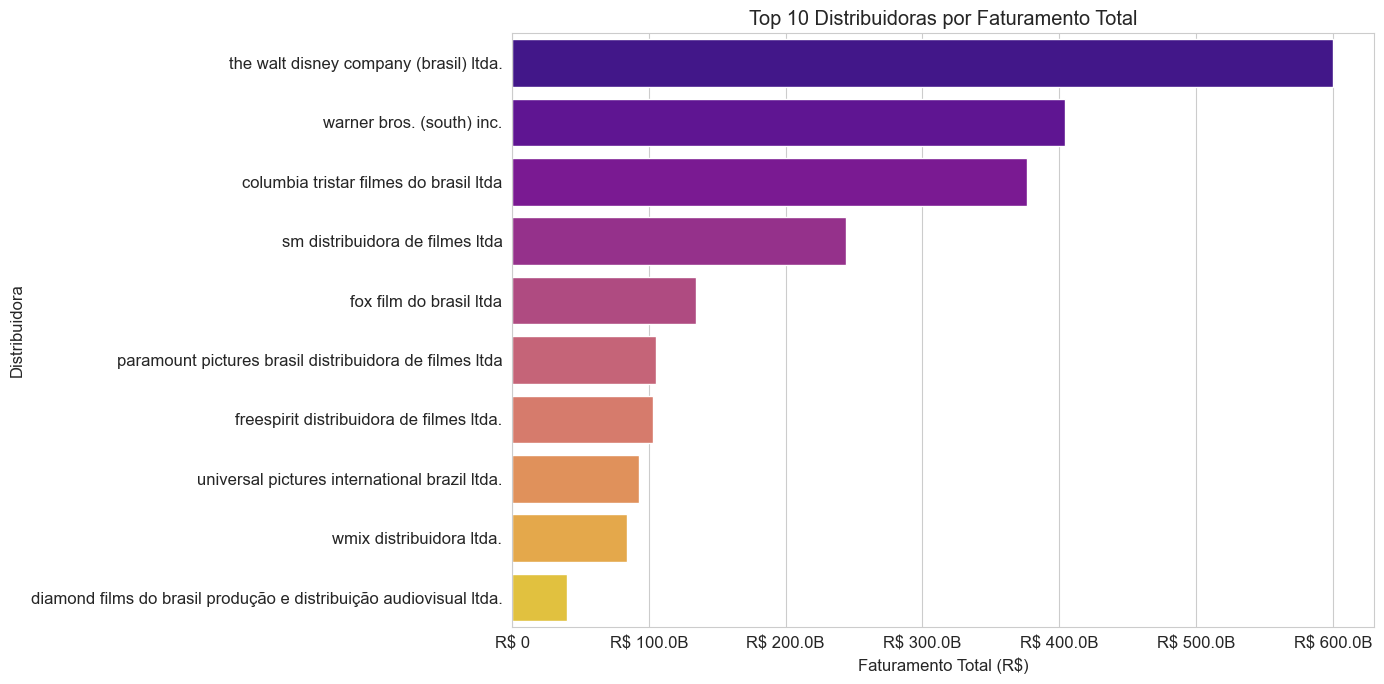

In [5]:
if df is not None:
    # limpar coluna RENDA_TOTAL (ex.: "R$ 1.234.567,89" -> 1234567.89)
    df['RENDA_TOTAL'] = df['RENDA_TOTAL'].astype(str).str.replace('R$', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).str.strip()
    df['RENDA_TOTAL'] = pd.to_numeric(df['RENDA_TOTAL'], errors='coerce').fillna(0)

    top_10_renda = df.groupby('RAZAO_SOCIAL_DISTRIBUIDORA')['RENDA_TOTAL'].sum().sort_values(ascending=False).head(10)

    print("\nTop 10 Distribuidoras por Faturamento Total:")
    display(top_10_renda.apply(lambda x: f"R$ {x:,.2f}"))

    # preparar dataframe para plot
    top10_df = top_10_renda.reset_index().rename(columns={'RAZAO_SOCIAL_DISTRIBUIDORA':'Distribuidora', 'RENDA_TOTAL':'RENDA_TOTAL'})

    # Gráfico de barras
    ax = sns.barplot(x='RENDA_TOTAL', y='Distribuidora', data=top10_df, palette='plasma')
    ax.set_title('Top 10 Distribuidoras por Faturamento Total')
    ax.set_xlabel('Faturamento Total (R$)')
    ax.set_ylabel('Distribuidora')

    # formatação dinâmica do eixo X (milhões / bilhões)
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e9:.1f}B' if abs(x) >= 1e9 else (f'R$ {x/1e6:.1f}M' if abs(x) >= 1e6 else f'R$ {x:,.0f}'))
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()

Top 10 Filmes de Maior Bilheteria


Top 10 Filmes com Maior Bilheteria:


,TITULO_ORIGINAL,RENDA_TOTAL,RAZAO_SOCIAL_DISTRIBUIDORA,DATA_LANCAMENTO_OBRA
544,inside out 2,44444406267,the walt disney company (brasil) ltda.,2024-06-20
2422,avengers: endgame,33862495558,the walt disney company (brasil) ltda.,2019-04-25
1621,spider-man: no way home,31743286699,columbia tristar filmes do brasil ltda,2021-12-16
2334,the lion king,26590397365,the walt disney company (brasil) ltda.,2019-07-18
1227,avatar: the way of water,24139562543,the walt disney company (brasil) ltda.,2022-12-15
2909,avengers: infinity war,23778177954,the walt disney company (brasil) ltda.,2018-04-26
80,lilo & stitch,21286497355,the walt disney company (brasil) ltda.,2025-05-22
995,barbie,20977082784,warner bros. (south) inc.,2023-07-20
322,moana 2,17779605864,the walt disney company (brasil) ltda.,2024-11-28
1504,doctor strange in the multiverse of madness,16943037936,the walt disney company (brasil) ltda.,2022-05-05


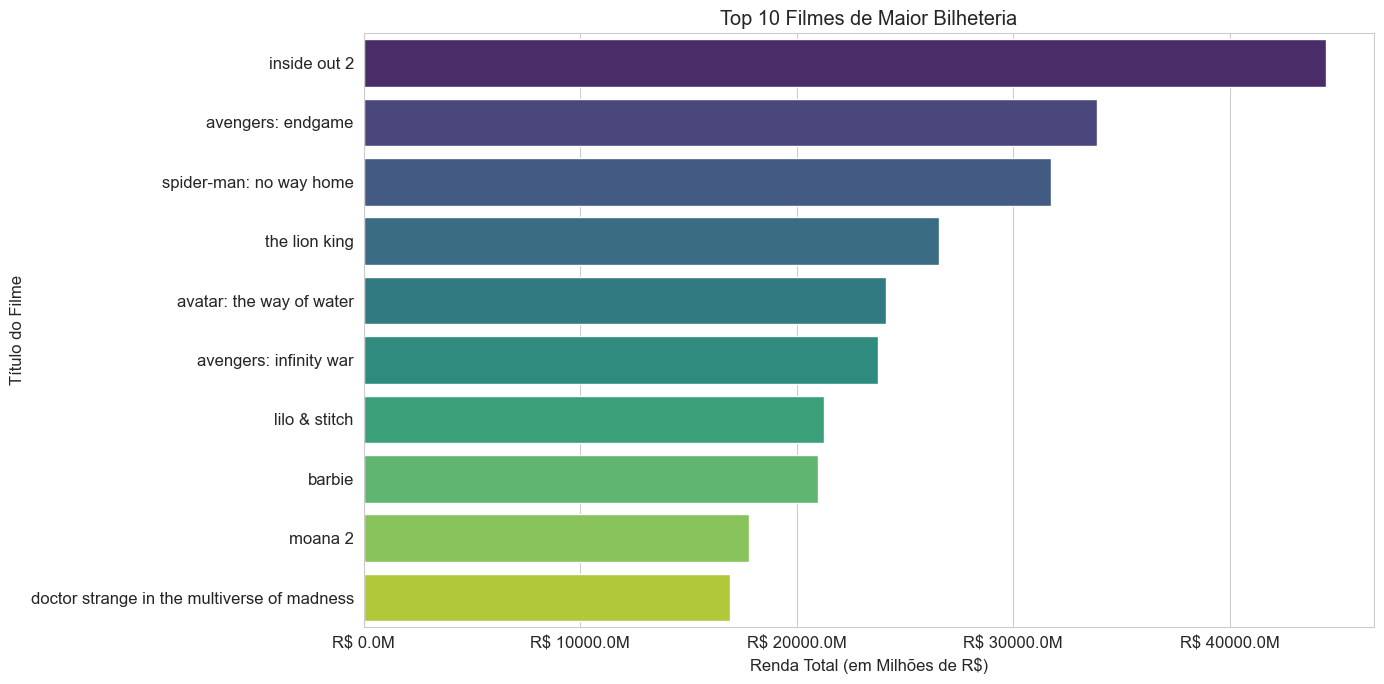

In [6]:
if df is not None:
    top_10_filmes_renda = df.sort_values(by='RENDA_TOTAL', ascending=False).head(10)
    
    print("\nTop 10 Filmes com Maior Bilheteria:")
    # Mostrando colunas relevantes
    display(top_10_filmes_renda[['TITULO_ORIGINAL', 'RENDA_TOTAL', 'RAZAO_SOCIAL_DISTRIBUIDORA', 'DATA_LANCAMENTO_OBRA']])

    # Gráfico de barras
    ax = sns.barplot(x='RENDA_TOTAL', y='TITULO_ORIGINAL', data=top_10_filmes_renda, hue='TITULO_ORIGINAL', palette='viridis', legend=False)
    ax.set_title('Top 10 Filmes de Maior Bilheteria')
    ax.set_xlabel('Renda Total (em Milhões de R$)')
    ax.set_ylabel('Título do Filme')

    # Formatação do eixo X para melhor leitura
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()

Faturamento por País de Origem da Obra


Top 10 Países por Faturamento Total Gerado (excluindo EUA e Canadá):


PAIS_OBRA
estados unidos    R$ 1,785,412,536,837.00
brasil              R$ 291,719,508,536.00
canadá               R$ 68,549,500,109.00
frança               R$ 37,223,818,129.00
china                R$ 33,600,075,550.00
alemanha             R$ 12,170,173,331.00
reino unido          R$ 11,887,864,870.00
espanha               R$ 9,904,666,768.00
austrália             R$ 9,362,186,322.00
japão                 R$ 8,920,177,093.00
Name: RENDA_TOTAL, dtype: object

C:\Users\alvea\AppData\Local\Temp\ipykernel_31364\2125330877.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_paises.values, y=top_10_paises.index, palette='crest', legend=False)


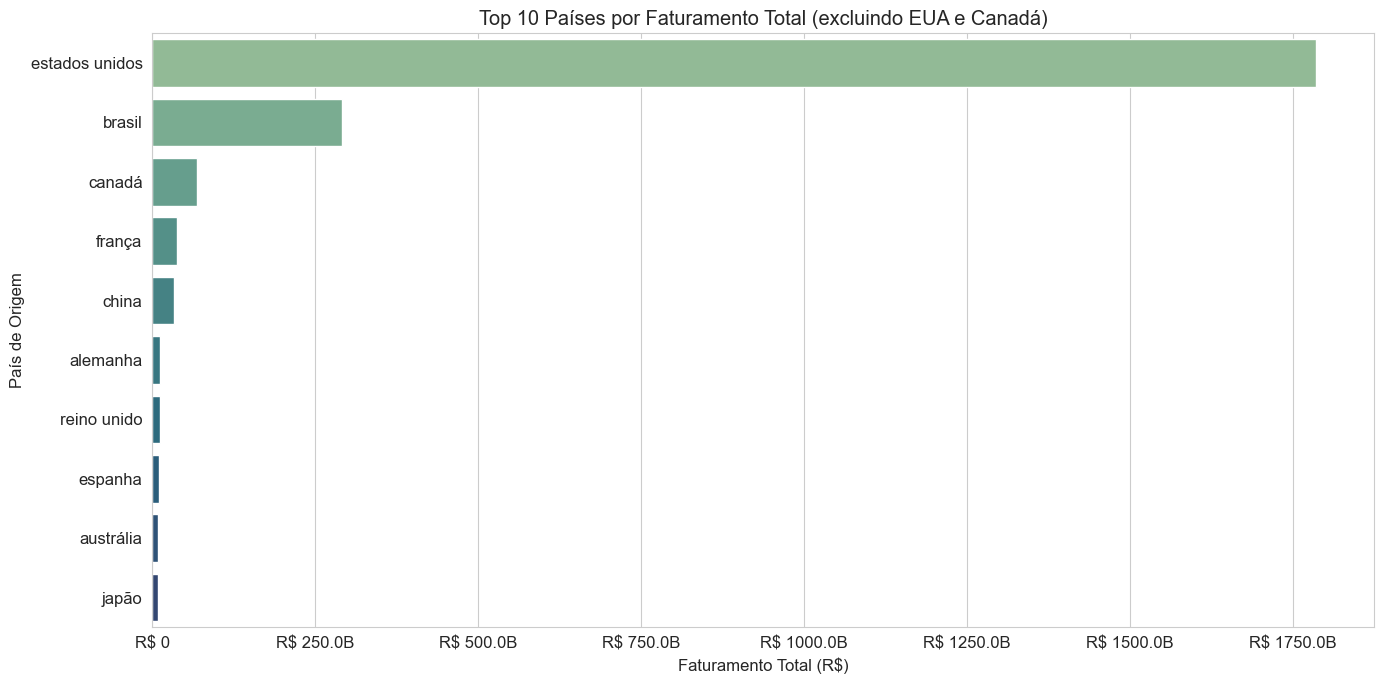

In [7]:
if df is not None:
    # garantir que RENDA_TOTAL é numérico
    df['RENDA_TOTAL'] = df['RENDA_TOTAL'].astype(str).str.replace('R$', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).str.strip()
    df['RENDA_TOTAL'] = pd.to_numeric(df['RENDA_TOTAL'], errors='coerce').fillna(0)

    # Excluir Estados Unidos e Canadá
    paises_excluidos = ['ESTADOS UNIDOS', 'CANADÁ', 'CANADA']
    df_filtrado_paises = df[~df['PAIS_OBRA'].isin(paises_excluidos)]

    # Usar o DataFrame filtrado para o agrupamento
    top_10_paises = df_filtrado_paises.groupby('PAIS_OBRA')['RENDA_TOTAL'].sum().sort_values(ascending=False).head(10)
    
    print("\nTop 10 Países por Faturamento Total Gerado (excluindo EUA e Canadá):")
    display(top_10_paises.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=top_10_paises.values, y=top_10_paises.index, palette='crest', legend=False)
    ax.set_title('Top 10 Países por Faturamento Total (excluindo EUA e Canadá)')
    ax.set_xlabel('Faturamento Total (R$)')
    ax.set_ylabel('País de Origem')
    
    # Formatação do eixo X (usa bilhões ou milhões quando apropriado)
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e9:.1f}B' if abs(x) >= 1e9 else (f'R$ {x/1e6:.1f}M' if abs(x) >= 1e6 else f'R$ {x:,.0f}'))
    ax.xaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

Desempenho por Gênero/Tipo de Obra


Faturamento Total por Tipo de Obra:


TIPO_OBRA
ficção                                R$ 1,876,719,701,180.00
animação                                R$ 405,115,792,930.00
variedades                               R$ 10,725,136,889.00
documentário                              R$ 6,176,047,106.00
vídeomusical                              R$ 3,098,664,185.00
religiosa                                 R$ 2,449,720,220.00
jornalística                                  R$ 3,103,103.00
não classificada                              R$ 1,222,128.00
manifestações e eventos esportivos              R$ 352,170.00
Name: RENDA_TOTAL, dtype: object

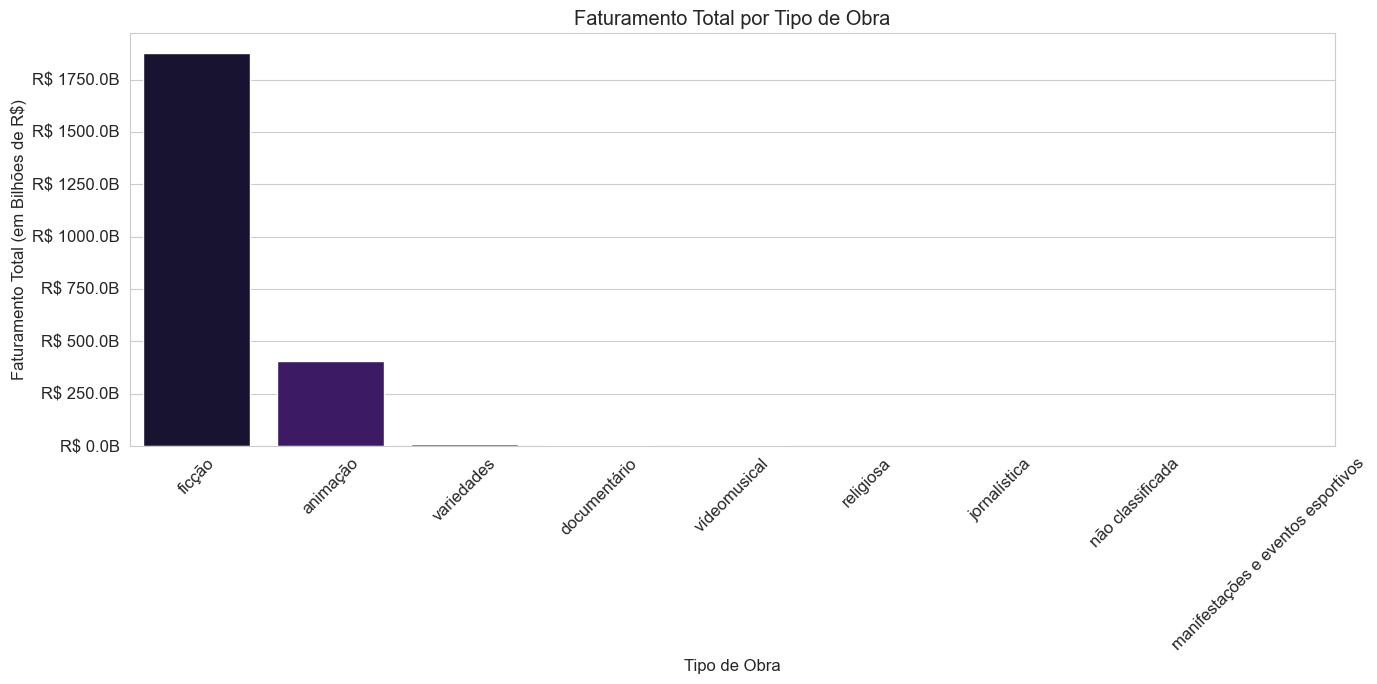

In [8]:
if df is not None:
    renda_por_tipo = df.groupby('TIPO_OBRA')['RENDA_TOTAL'].sum().sort_values(ascending=False)
    
    print("\nFaturamento Total por Tipo de Obra:")
    display(renda_por_tipo.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=renda_por_tipo.index, y=renda_por_tipo.values, hue=renda_por_tipo.index, palette='magma', legend=False)
    ax.set_title('Faturamento Total por Tipo de Obra')
    ax.set_xlabel('Tipo de Obra')
    ax.set_ylabel('Faturamento Total (em Bilhões de R$)')
    
    # Formatação do eixo Y
    formatter = FuncFormatter(lambda y, pos: f'R$ {y/1e9:.1f}B')
    ax.yaxis.set_major_formatter(formatter)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Faturamento por Tipo de Obra (Excluindo Ficção e Animação)


Faturamento Total por Tipo de Obra (Excluindo Ficção e Animação):


TIPO_OBRA
ficção                                R$ 1,876,719,701,180.00
animação                                R$ 405,115,792,930.00
variedades                               R$ 10,725,136,889.00
documentário                              R$ 6,176,047,106.00
vídeomusical                              R$ 3,098,664,185.00
religiosa                                 R$ 2,449,720,220.00
jornalística                                  R$ 3,103,103.00
não classificada                              R$ 1,222,128.00
manifestações e eventos esportivos              R$ 352,170.00
Name: RENDA_TOTAL, dtype: object

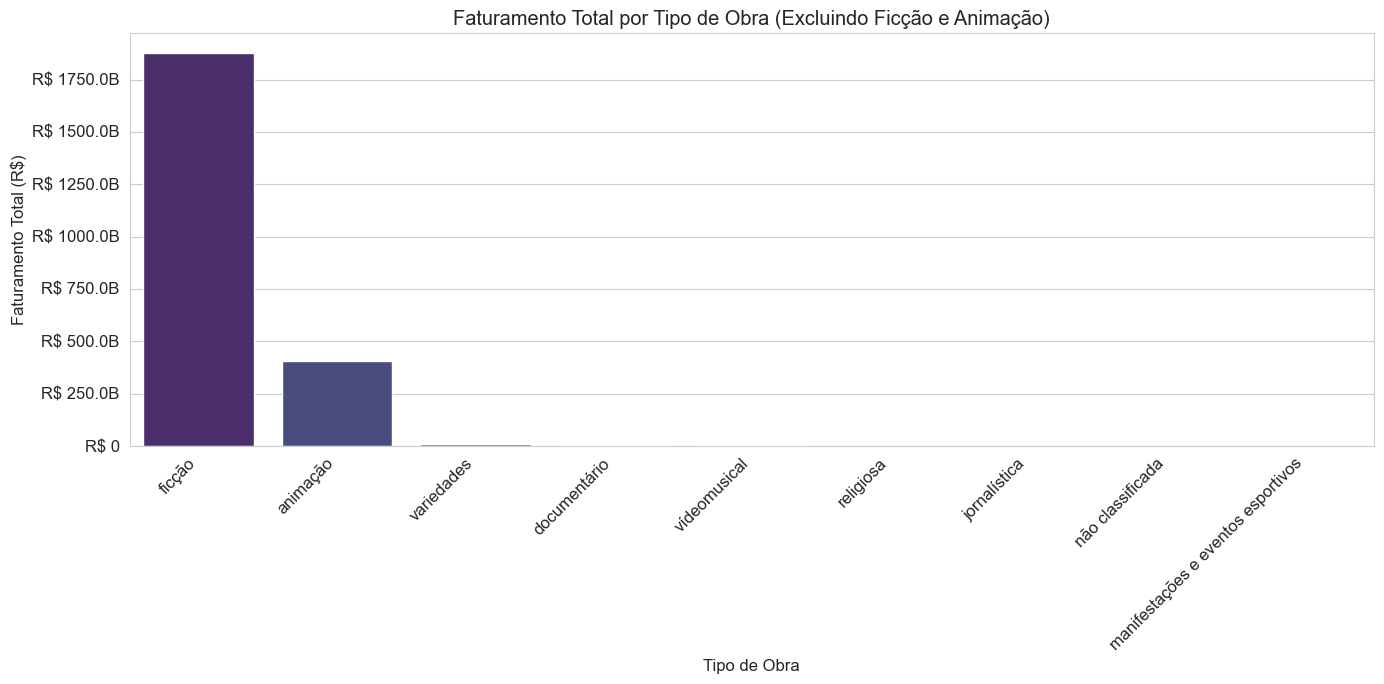

In [9]:
if df is not None:
    # Excluir tipos de obra: Ficção e Animação
    tipos_excluidos = ['FICÇÃO', 'ANIMAÇÃO', 'FICCAO', 'ANIMACAO']
    df_filtrado_tipos = df[~df['TIPO_OBRA'].isin(tipos_excluidos)]
    
    # Agrupar por tipo de obra
    renda_por_tipo_filtrado = df_filtrado_tipos.groupby('TIPO_OBRA')['RENDA_TOTAL'].sum().sort_values(ascending=False)
    
    print("\nFaturamento Total por Tipo de Obra (Excluindo Ficção e Animação):")
    display(renda_por_tipo_filtrado.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=renda_por_tipo_filtrado.index, y=renda_por_tipo_filtrado.values, 
                     hue=renda_por_tipo_filtrado.index, palette='viridis', legend=False)
    ax.set_title('Faturamento Total por Tipo de Obra (Excluindo Ficção e Animação)')
    ax.set_xlabel('Tipo de Obra')
    ax.set_ylabel('Faturamento Total (R$)')
    
    # Formatação dinâmica do eixo Y (bilhões/milhões)
    formatter = FuncFormatter(lambda y, pos: f'R$ {y/1e9:.1f}B' if abs(y) >= 1e9 else (f'R$ {y/1e6:.1f}M' if abs(y) >= 1e6 else f'R$ {y:,.0f}'))
    ax.yaxis.set_major_formatter(formatter)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Relação entre Público e Renda

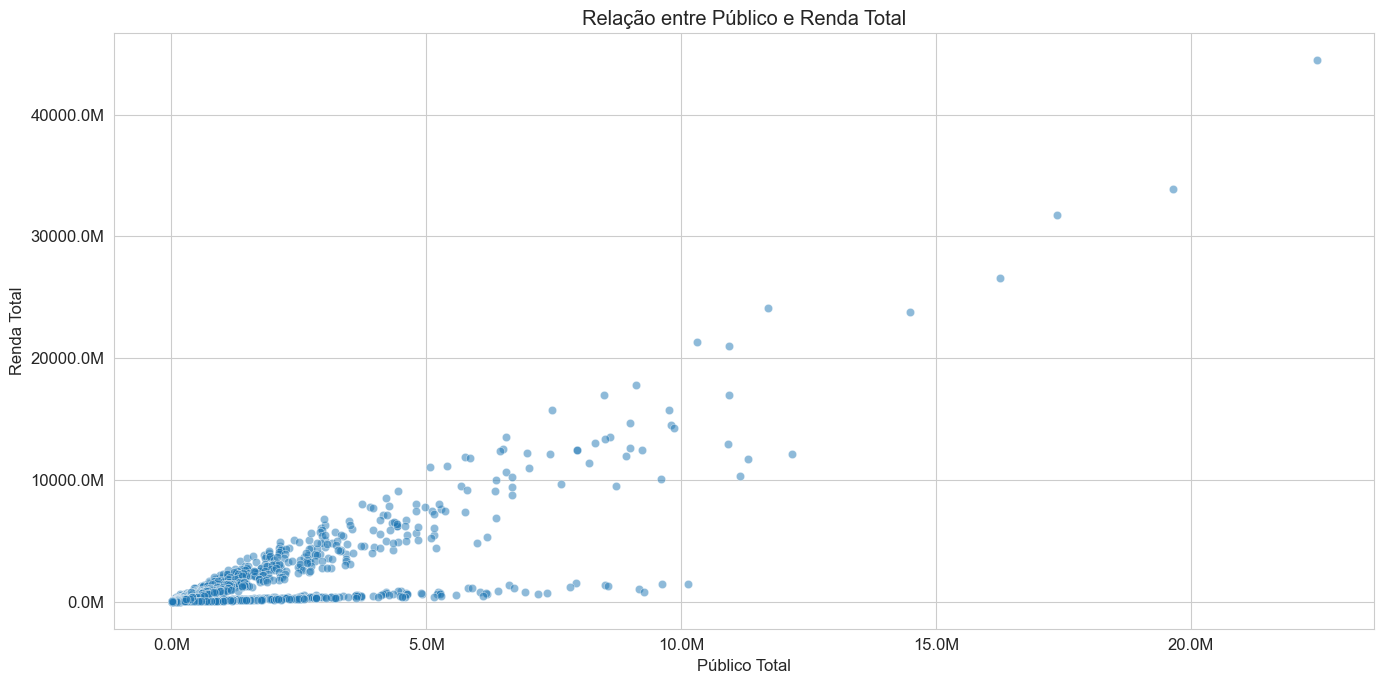

In [10]:
if df is not None:
    # Para uma melhor visualização, podemos filtrar filmes com renda e público muito baixos
    df_filtrado = df[(df['PUBLICO_TOTAL'] > 1000) & (df['RENDA_TOTAL'] > 10000)]

    ax = sns.scatterplot(data=df_filtrado, x='PUBLICO_TOTAL', y='RENDA_TOTAL', alpha=0.5)
    ax.set_title('Relação entre Público e Renda Total')
    ax.set_xlabel('Público Total')
    ax.set_ylabel('Renda Total')
    
    # Formatação dos eixos
    formatter_milhoes = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(formatter_milhoes)
    ax.yaxis.set_major_formatter(formatter_milhoes)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes por Ticket Médio

C:\Users\alvea\AppData\Local\Temp\ipykernel_31364\3456312280.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


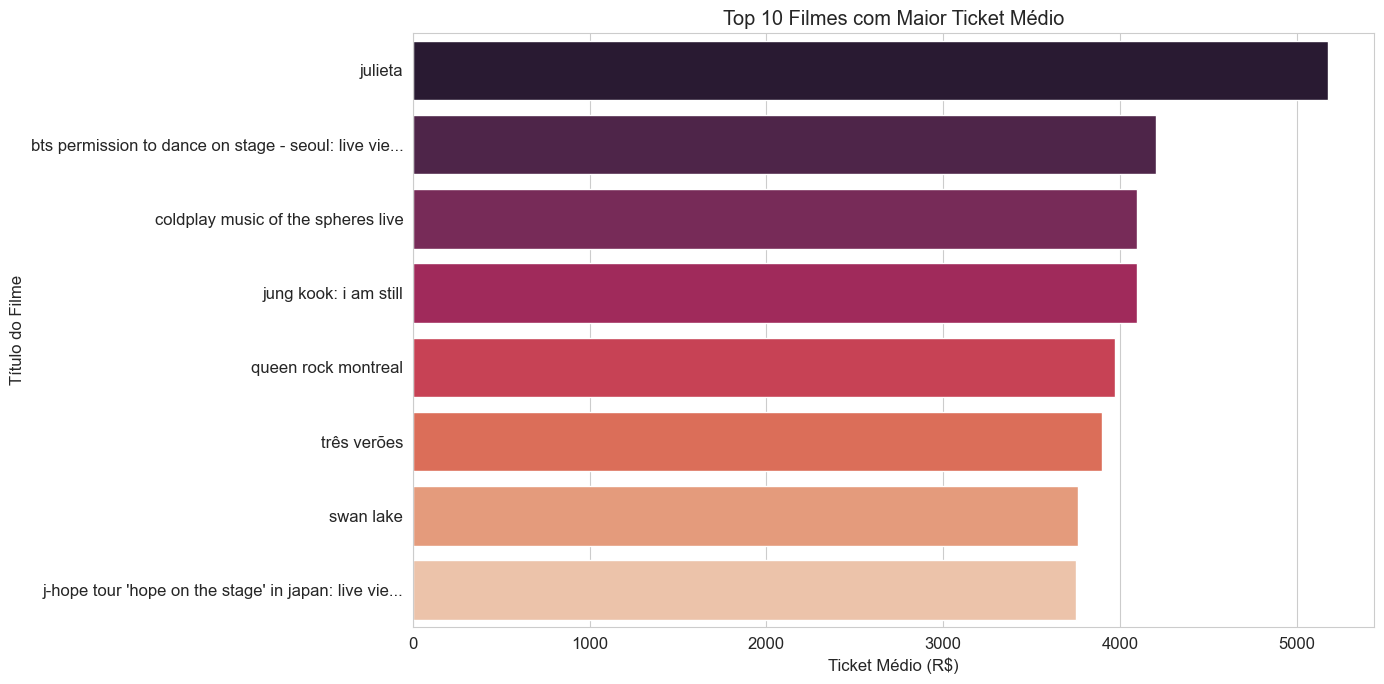

In [11]:
if df is not None:
    # Calculando o ticket médio
    df['ticket_medio'] = df.apply(
        lambda row: row['RENDA_TOTAL'] / row['PUBLICO_TOTAL'] if row['PUBLICO_TOTAL'] > 0 else 0, 
        axis=1
    )
    
    # Aplicando método IQR para identificar outliers
    Q1_ticket = df['ticket_medio'].quantile(0.25)
    Q3_ticket = df['ticket_medio'].quantile(0.75)
    IQR_ticket = Q3_ticket - Q1_ticket
    
    limite_superior_ticket = Q3_ticket + 1.5 * IQR_ticket
    
    # Identificando outliers altos (acima do limite superior)
    outliers_alto = df[df['ticket_medio'] > limite_superior_ticket]
    
    # Selecionando os top 10 outliers para visualização
    top_10_ticket = outliers_alto.nlargest(10, 'ticket_medio')
    
    # Gráfico de barras dos top 10 tickets médios
    ax = sns.barplot(data=top_10_ticket, y='TITULO_ORIGINAL', x='ticket_medio', 
                    hue='TITULO_ORIGINAL', palette='rocket', legend=False)
    ax.set_title('Top 10 Filmes com Maior Ticket Médio')
    ax.set_xlabel('Ticket Médio (R$)')
    ax.set_ylabel('Título do Filme')
    
    # Truncar títulos longos para melhor visualização
    labels = [label.get_text()[:50] + '...' if len(label.get_text()) > 50 else label.get_text() 
             for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes com Menor Ticket Médio

C:\Users\alvea\AppData\Local\Temp\ipykernel_31364\3251627081.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


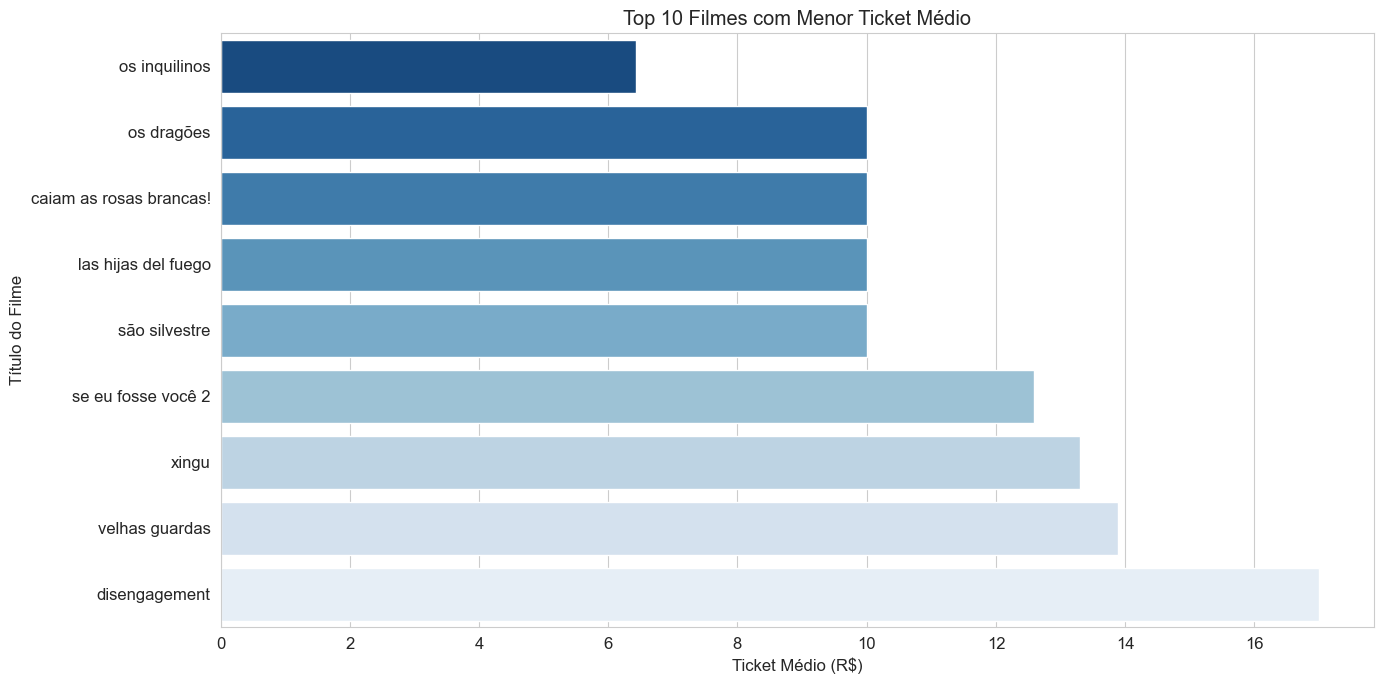

In [12]:
if df is not None:
    # Usando os dados já calculados de ticket médio da célula anterior
    # Filtrar apenas filmes com público maior que 0 para evitar divisões por zero
    df_valido = df[df['PUBLICO_TOTAL'] > 0].copy()
    
    # Aplicando método IQR para identificar outliers baixos
    Q1_ticket = df_valido['ticket_medio'].quantile(0.25)
    IQR_ticket = df_valido['ticket_medio'].quantile(0.75) - Q1_ticket
    
    limite_inferior_ticket = Q1_ticket - 1.5 * IQR_ticket
    
    # Identificando outliers baixos (abaixo do limite inferior)
    outliers_baixo = df_valido[df_valido['ticket_medio'] < limite_inferior_ticket]
    
    # Se não há outliers baixos suficientes, pegar os 10 menores valores
    if len(outliers_baixo) < 10:
        top_10_menores = df_valido.nsmallest(10, 'ticket_medio')
    else:
        top_10_menores = outliers_baixo.nsmallest(10, 'ticket_medio')
    
    # Gráfico de barras dos top 10 menores tickets médios
    ax = sns.barplot(data=top_10_menores, y='TITULO_ORIGINAL', x='ticket_medio', 
                    hue='TITULO_ORIGINAL', palette='Blues_r', legend=False)
    ax.set_title('Top 10 Filmes com Menor Ticket Médio')
    ax.set_xlabel('Ticket Médio (R$)')
    ax.set_ylabel('Título do Filme')
    
    # Truncar títulos longos para melhor visualização
    labels = [label.get_text()[:50] + '...' if len(label.get_text()) > 50 else label.get_text() 
             for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.tight_layout()
    plt.show()

Matriz de Correlação

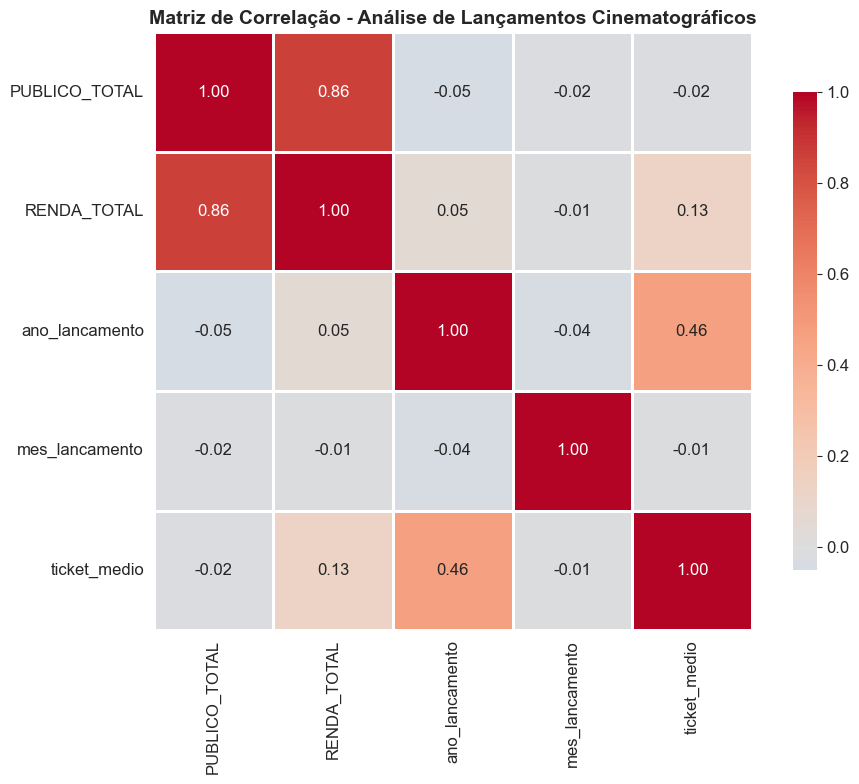


=== Interpretação da Correlação ===
Correlação RENDA_TOTAL vs PUBLICO_TOTAL: 0.856
Correlação ticket_medio vs PUBLICO_TOTAL: -0.022
Correlação ano_lancamento vs RENDA_TOTAL: 0.050


In [13]:
if df is not None:
    # Garantir que DATA_LANCAMENTO_OBRA está no formato datetime
    df['DATA_LANCAMENTO_OBRA'] = pd.to_datetime(df['DATA_LANCAMENTO_OBRA'], errors='coerce')
    
    # Extrair ano e mês da data de lançamento
    df['ano_lancamento'] = df['DATA_LANCAMENTO_OBRA'].dt.year
    df['mes_lancamento'] = df['DATA_LANCAMENTO_OBRA'].dt.month
    
    # Garantir que PUBLICO_TOTAL é numérico
    df['PUBLICO_TOTAL'] = pd.to_numeric(df['PUBLICO_TOTAL'], errors='coerce').fillna(0)
    
    # Calcular o ticket médio 
    df['ticket_medio'] = df.apply(
        lambda row: row['RENDA_TOTAL'] / row['PUBLICO_TOTAL'] if row['PUBLICO_TOTAL'] > 0 else 0, 
        axis=1
    )
    
    # Selecionar colunas numéricas para correlação
    colunas_corr = ['PUBLICO_TOTAL', 'RENDA_TOTAL', 'ano_lancamento', 'mes_lancamento', 'ticket_medio']
    
    # Filtrar apenas linhas com valores válidos
    df_corr = df[colunas_corr].dropna()
    matriz_corr = df_corr.corr()
    
    # Exibir a matriz com um mapa de calor
    plt.figure(figsize=(10, 8))
    sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlação - Análise de Lançamentos Cinematográficos', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n=== Interpretação da Correlação ===")
    print(f"Correlação RENDA_TOTAL vs PUBLICO_TOTAL: {matriz_corr.loc['RENDA_TOTAL', 'PUBLICO_TOTAL']:.3f}")
    print(f"Correlação ticket_medio vs PUBLICO_TOTAL: {matriz_corr.loc['ticket_medio', 'PUBLICO_TOTAL']:.3f}")
    print(f"Correlação ano_lancamento vs RENDA_TOTAL: {matriz_corr.loc['ano_lancamento', 'RENDA_TOTAL']:.3f}")

Principais Correlações Encontradas
Aqui estão as observações mais significativas retiradas da Matriz:

1. Correlação Positiva Forte (0.86)
Variáveis: PUBLICO_TOTAL e RENDA_TOTAL

Interpretação: Este é o relacionamento mais forte na matriz (0.86). Há uma correlação positiva muito forte entre o público total e a renda total.

O que significa: Isso é esperado e lógico. Quanto mais pessoas assistem a um filme (maior público), maior é a receita (renda) gerada por ele.

2. Correlação Positiva Moderada (0.46)
Variáveis: ano_lancamento e ticket_medio

Interpretação: Há uma correlação positiva moderada (0.46) entre o ano de lançamento e o preço médio do ingresso.

O que significa: À medida que os anos passam (filmes mais novos), o preço médio do ingresso tende a ser mais alto. Isso reflete tendências econômicas do mundo real, como a inflação e o aumento geral dos custos, que fazem com que os ingressos de cinema fiquem mais caros ao longo do tempo.